In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-05-13 13:08:02.400685: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 13:08:02.421673: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-13 13:08:02.421703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 13:08:02.422365: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-13 13:08:02.426275: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [ ]:
dataset_id = 'eshard'
traces_dim = 1400

n_prof= 90000
import gc

lm = "HW"
target_byte = 2
path = "./datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


## Training model and plotting PI evolution

In [ ]:
import gc

n_epochs = 100
batch_size=400
model = mlp_eshard(9,traces_dim)
# Set training to false to use saved checkpoints
# Set training to true to retrain the model
# Note: Results will vary for different runs due to the random nature of the training process.
# Especially Patching results will require manual intervention when retraining.
training = False
pi_prof, pi_attack = [], []
model_name = f"mlp_eshard_"
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output if layer > 0 else [] for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")

if not training:
        for i in range(n_epochs):

                only_reload(i+1)
                pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
                pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
                print(i, pi_prof[-1], pi_attack[-1])
                gc.collect()
else:
        for i in range(n_epochs):
                model.fit(
                        x=dataset.x_profiling,
                        y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
                        batch_size=batch_size,
                        verbose=2,
                        epochs=1,
                        shuffle=True)
                model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
                pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
                pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
                print(i, pi_prof[-1], pi_attack[-1])
                gc.collect()

Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 1400)]            0         
                                                                 
 dense_8 (Dense)             (None, 40)                56040     
                                                                 
 dense_9 (Dense)             (None, 40)                1640      
                                                                 
 dense_10 (Dense)            (None, 40)                1640      
                                                                 
 dense_11 (Dense)            (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 61329 (239.57 KB)
Trainable params: 61329

313/313 [==============================] - 0s 1ms/step
0 0.00867021073889905 -0.01404719670071114


313/313 [==============================] - 0s 1ms/step
1 0.01376263017249351 -0.011192915084499988


313/313 [==============================] - 0s 1ms/step
2 0.015532063766243456 -0.009979166915554505


313/313 [==============================] - 0s 1ms/step
3 0.04609996232581361 0.016087465164523064


...

313/313 [==============================] - 0s 1ms/step
5 0.0966499012906571 0.05026527888522627


313/313 [==============================] - 0s 1ms/step
6 0.0999522541959306 0.048842900345186985


313/313 [==============================] - 0s 1ms/step
7 0.09159655961585192 0.05007892634616411


313/313 [==============================] - 0s 1ms/step


KeyboardInterrupt: 

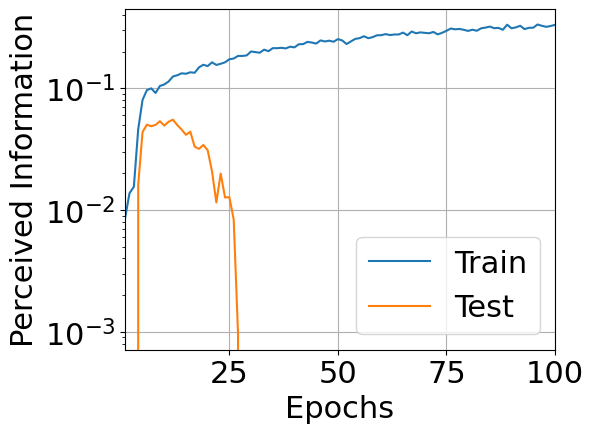

In [7]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#print(len(pi_attack))
plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_attack, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1, 100])
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("PI_eshard.png", dpi=200)
plt.show()


## Logit Visualization

2/2 [==============================] - 0s 2ms/step


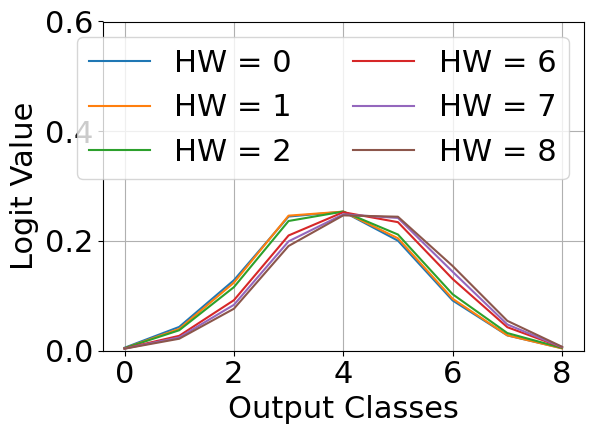

In [10]:

reload_model(5)
out_logits = []
for i in [0,1,2, 6, 7,8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()

## PCA stuff


313/313 [==============================] - 0s 2ms/step


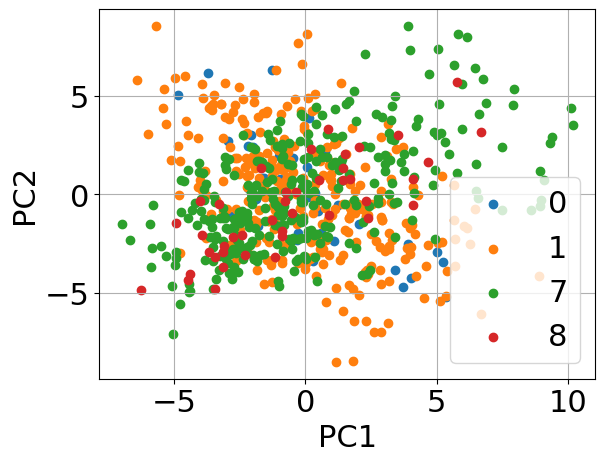

In [12]:
layer = 1
comp_n= 3
from sklearn.decomposition import PCA
gc.collect()
reload_model(5)
new_pca = PCA(n_components=comp_n)

#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 1
in2 = 2
for i in [0,1,7,8]:
    indices = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label=i)
plt.legend()
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.grid()
plt.show()


2/2 [==============================] - 0s 2ms/step


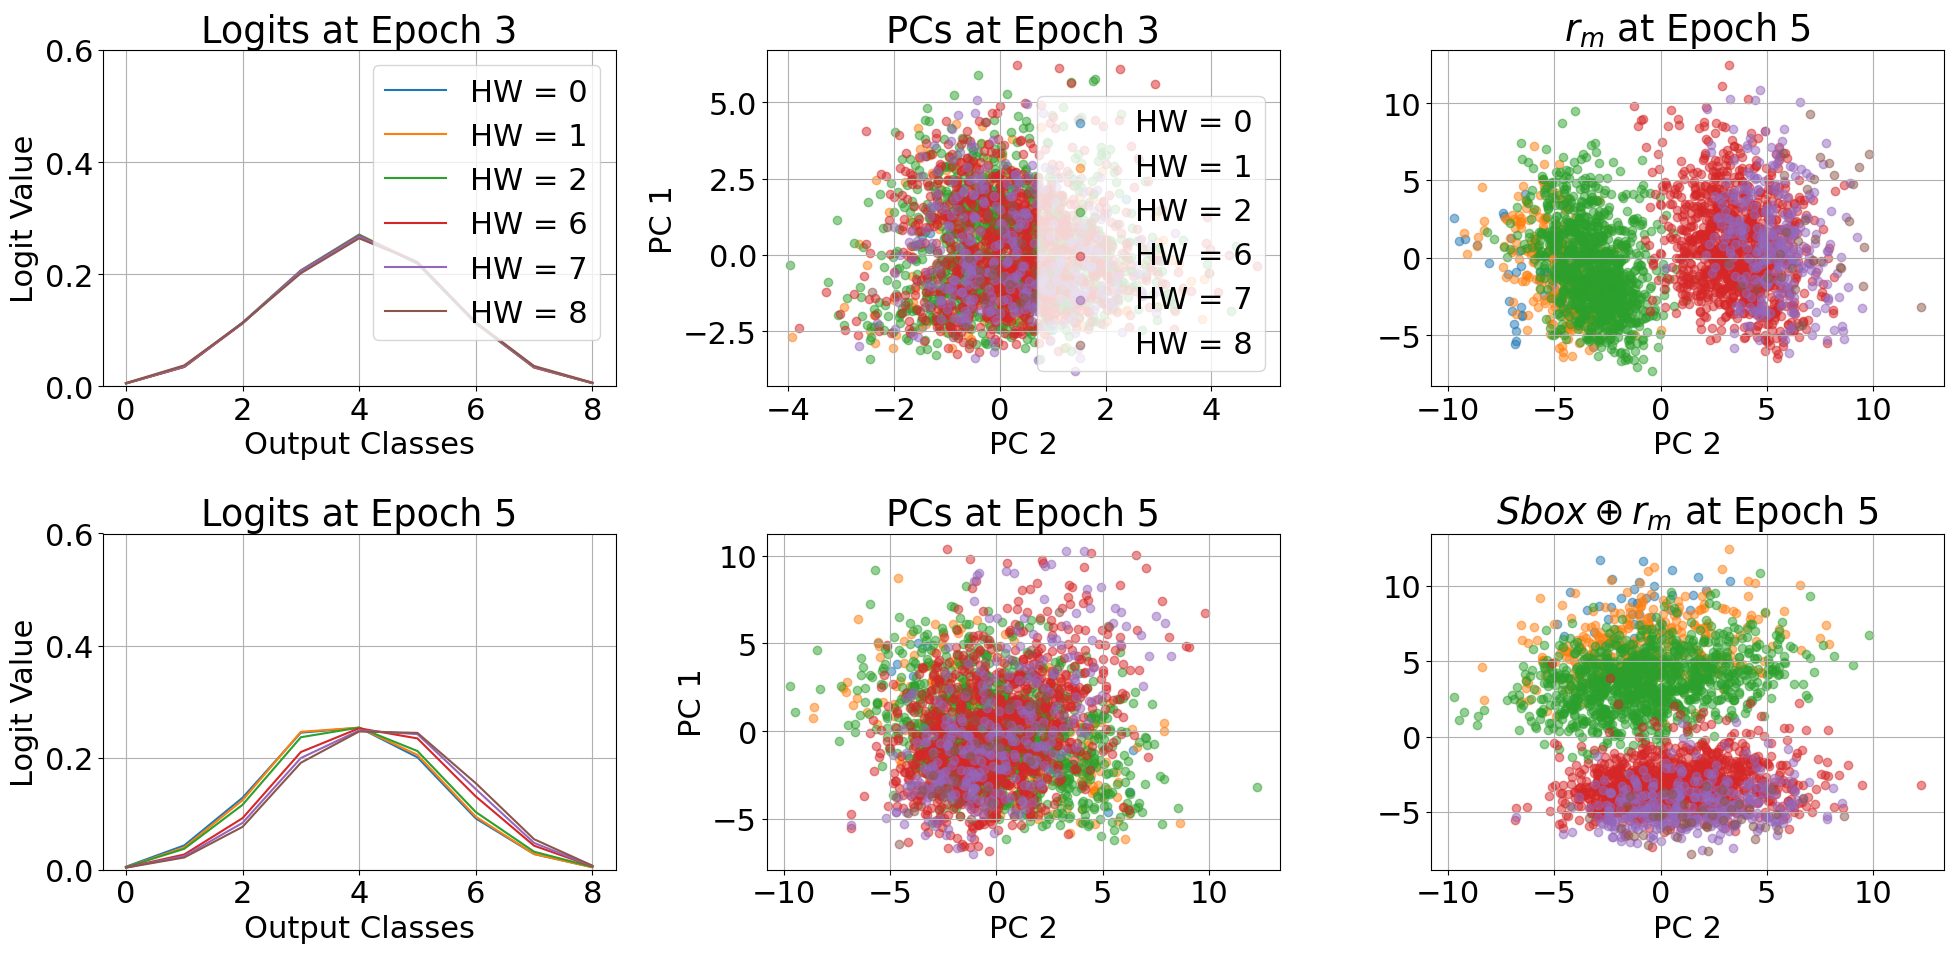

In [15]:
reload_model(3)

font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#matplotlib.rc('font', **font)
# Prepare logits
out_logits = []
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.subplot(2, 3, 1)
plt.title("Logits at Epoch 3")
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


in1, in2 = 2, 1

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 2)
plt.title("PCs at Epoch 3")
in1, in2 = 2, 1
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
# plt.subplot(2, 3, 3)
# rm = hw(dataset.share1_attack[target_byte].astype(np.uint8))
# for i in [0, 1, 2, 6, 7, 8]:
#     on, = np.where(rm == i)
#     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
#                 label=f"HW = {i}", alpha=0.5)
# plt.xlabel(f"PC {in1}")
# #plt.ylabel(f"PC {in2}")
# plt.grid()
reload_model(5)
plt.subplot(2, 3, 4)
plt.title("Logits at Epoch 5")
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
#plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

plt.subplot(2, 3, 5)
plt.title("PCs at Epoch 5")
in1, in2 = 2, 1
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
#plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 3)
plt.title("$r_m$ at Epoch 5")
rm = hw(dataset.share1_attack[target_byte].astype(np.uint8))
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(rm == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()

plt.subplot(2, 3, 6)
plt.title("$Sbox \oplus r_m$ at Epoch 5")
rm = hw(dataset.share2_attack[target_byte].astype(np.uint8))
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(rm == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
#plt.legend(loc=4)

# Save or show the combined plot
plt.tight_layout()
plt.savefig(f"combined_plots_eshard_lowest.png", dpi=20)
plt.savefig(f"combined_plots_eshard_lower.png", dpi=100)
plt.savefig(f"combined_plots_eshard.png", dpi=200)
plt.show()

## Activation Patching

In [19]:
#Patching code

new_model_for_probe = Model(model.layers[layer+1].input, model.output)
copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 2] = -7.5




theta = np.radians(25)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
copy_for_patch[:, 1:] = copy_for_patch[:, 1:] @rot_matrix
predicts_s1 = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
hw_values_s1 = np.argmax(predicts_s1, axis=1)
prior = np.median(predicts_s1, axis=0)

low_hw_s1 = np.sum(predicts_s1[:, 0:4], axis=1)
high_hw_s1 = np.sum(predicts_s1[:, 5:9], axis=1)
hw_normalized_values_s1 = np.argmax(predicts_s1/prior, axis=1)

copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 1] =-7.5

copy_for_patch[:, 1:] = copy_for_patch[:, 1:] @rot_matrix
predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
hw_values_s2 = np.argmax(predicts, axis=1)

low_hw_s2 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s2 = np.sum(predicts[:, 5:9], axis=1)

#Order the patching outputs and leverage known HW distribution
# To extract more accurate HW values (Model only predicts (3-5) due to HW prior)
print(np.mean(low_hw_s1-high_hw_s1), np.std(low_hw_s1-high_hw_s1))
diff_s1 = high_hw_s1 - low_hw_s1
diff_s2 = high_hw_s2- low_hw_s2

final_hw_values_s1 = np.zeros(len(dataset.x_attack))
final_hw_values_s2 = np.zeros(len(dataset.x_attack))

argsort_s1 = np.argsort(diff_s1).astype(int)
argsort_s2 = np.argsort(diff_s2).astype(int)
hw_prior = np.zeros(9)
for i in range(256):
    hw_prior[hw(i)] += 1
hw_prior/=256
start_index = 0
for i in range(9):
    num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
    if i == 4:
        num_vals +=4
    print(num_vals)
    final_hw_values_s1[argsort_s1[start_index:start_index+num_vals]] = i
    final_hw_values_s2[argsort_s2[start_index:start_index+num_vals]] = i
    start_index += num_vals
print(start_index)

313/313 [==============================] - 0s 934us/step
-0.116418935 0.27541846
39
312
1093
2187
2738
2187
1093
312
39
10000


-0.116418555 0.27541834
39
312
1093
2187
2738
2187
1093
312
39
10000


0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39
0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39


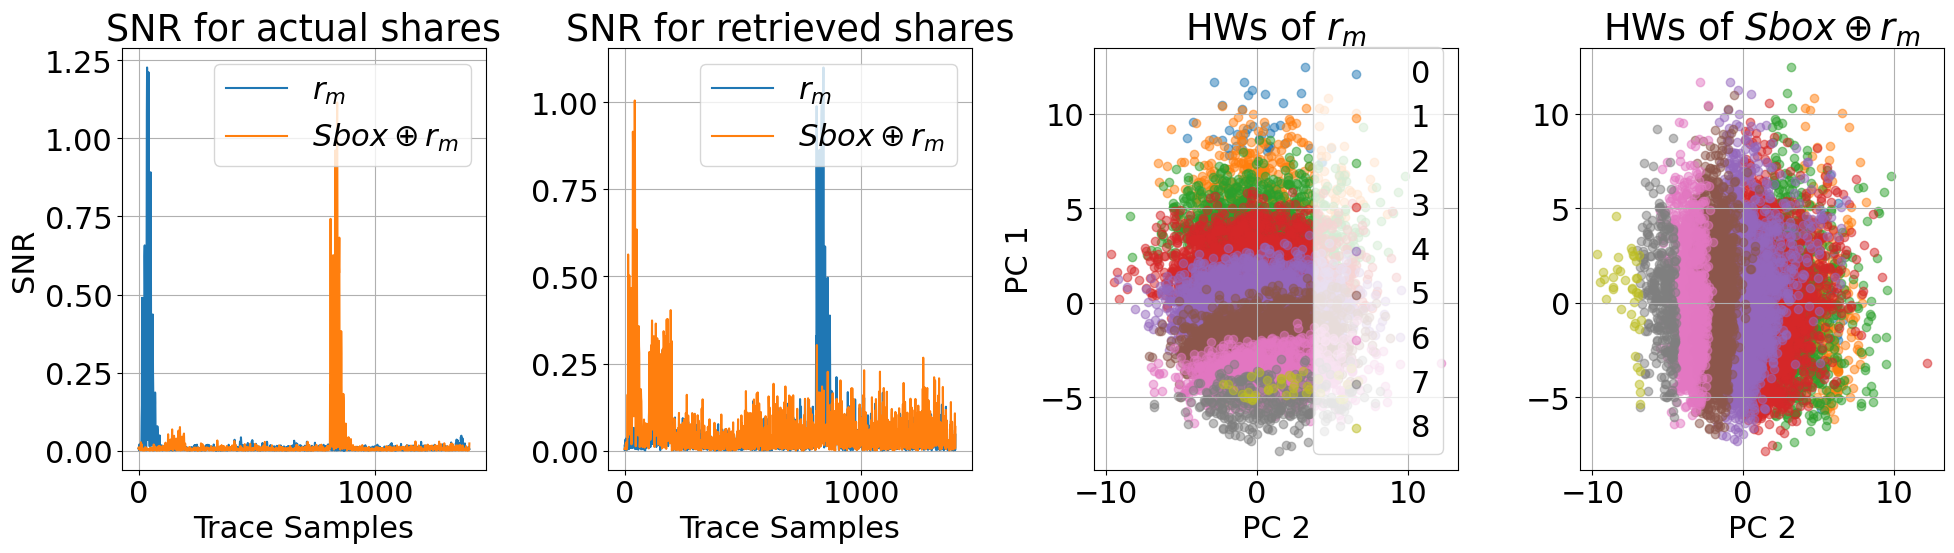

In [20]:
plt.figure(figsize=(20, 6))  # Adjust the figure size for 1x3 layout
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
# Subplot 1: Logits
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.subplot(1, 4, 3)
in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.title("HWs of $r_m$")
plt.grid()

plt.legend(loc=4)

in1 = 2
in2 = 1
plt.subplot(1,4,4)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.title("HWs of $Sbox \oplus r_m$")
for i in range(0, 9):

     on = np.where(final_hw_values_s2==i)[0]
     #print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
plt.grid()
#plt.legend()
plt.subplot(1,4,2)
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s1), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s2), label="$Sbox \oplus r_m$") 

plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
#plt.ylabel("SNR")


plt.subplot(1,4,1)
plt.plot(snr_fast(dataset.x_attack, hw(dataset.share1_attack[target_byte].astype(np.uint8))), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, hw(dataset.share2_attack[target_byte].astype(np.uint8))), label="$Sbox \oplus r_m$") 
plt.title("SNR for actual shares")
plt.xlabel("Trace Samples")
plt.ylabel("SNR")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
plt.savefig("Combined_patch_ehard_lowest_res.png", dpi=20)
plt.savefig("Combined_patch_eshard_lower_res.png", dpi=100)
plt.savefig("Combined_patch_eshard.png", dpi=200)
plt.show()